# CTR Impact Features

By Yusuf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/data_cleaned_full.csv')

## 1. Impression to View Rate
impression_to_view_rate = views / impressions

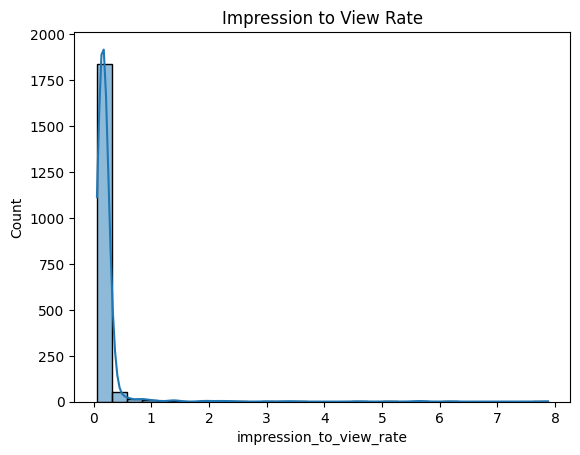

In [3]:
df['impression_to_view_rate'] = df['views'] / (df['impressions'] + 1)
sns.histplot(df['impression_to_view_rate'], bins=30, kde=True)
plt.title('Impression to View Rate')
plt.show()

## 2. CTR Normalized
ctr_normalized = ctr / 100

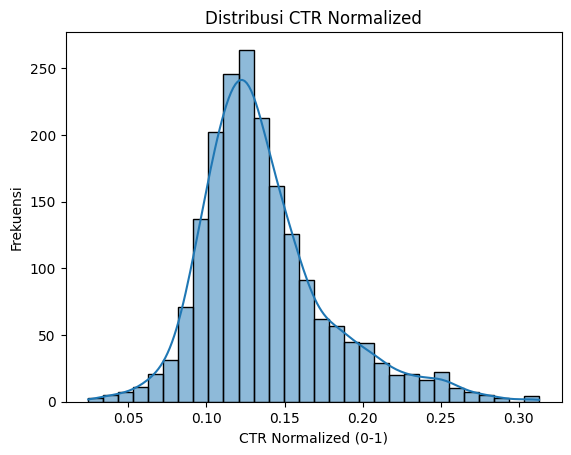

count    1935.000000
mean        0.137216
std         0.041324
min         0.024300
25%         0.110800
50%         0.129000
75%         0.154450
max         0.313000
Name: ctr_normalized, dtype: float64


In [4]:
df['ctr_normalized'] = df['ctr(%)'] / 100

sns.histplot(df['ctr_normalized'], bins=30, kde=True)
plt.title('Distribusi CTR Normalized')
plt.xlabel('CTR Normalized (0-1)')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_normalized'].describe())

## 3. CTR Impression Score
ctr_impression_score = ctr_normalized * impression_to_view_rate

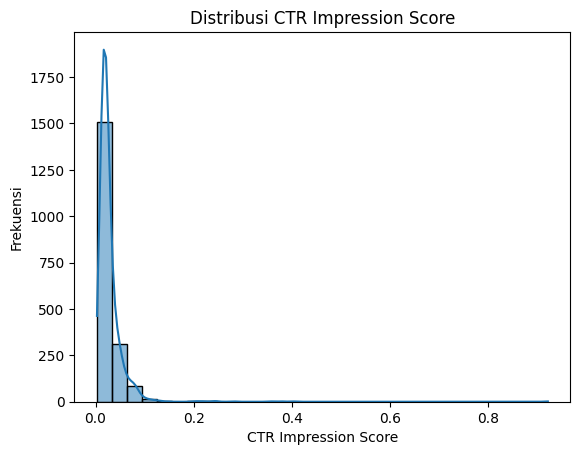

count    1935.000000
mean        0.028327
std         0.032587
min         0.002870
25%         0.015721
50%         0.020872
75%         0.031004
max         0.921457
Name: ctr_impression_score, dtype: float64


In [5]:
df['ctr_impression_score'] = df['ctr_normalized'] * df['impression_to_view_rate']

sns.histplot(df['ctr_impression_score'], bins=30, kde=True)
plt.title('Distribusi CTR Impression Score')
plt.xlabel('CTR Impression Score')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_impression_score'].describe())

## 4. CTR Category
ctr_category = bin ctr into Low(<3%), Mid(3-7%), High(>7%)

In [6]:
df['ctr_category'] = pd.cut(
    df['ctr(%)'],
    bins=[0, 3, 7, float('inf')],
    labels=['Low', 'Mid', 'High'],
    right=True
)

print(df['ctr_category'].value_counts())

ctr_category
High    1895
Mid       39
Low        1
Name: count, dtype: int64


### CTR Category Analysis

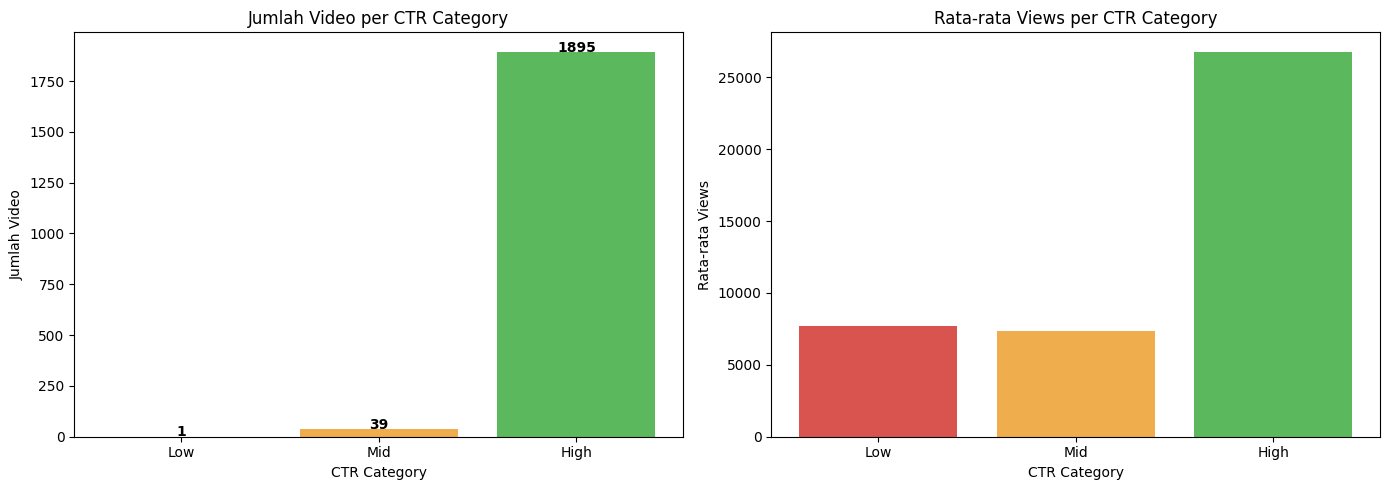


Statistik Views per CTR Category:
               count      mean       std     min     25%      50%      75%  \
ctr_category                                                                 
Low              1.0   7697.00       NaN  7697.0  7697.0   7697.0   7697.0   
Mid             39.0   7365.82   5990.33   296.0  2034.0   5914.0  10735.5   
High          1895.0  26794.78  44579.39   337.0  7064.0  13025.0  28025.0   

                   max  
ctr_category            
Low             7697.0  
Mid            23822.0  
High          827102.0  


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ctr_counts = df['ctr_category'].value_counts().reindex(['Low', 'Mid', 'High'])
axes[0].bar(ctr_counts.index, ctr_counts.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[0].set_title('Jumlah Video per CTR Category')
axes[0].set_xlabel('CTR Category')
axes[0].set_ylabel('Jumlah Video')
for i, v in enumerate(ctr_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

avg_views = df.groupby('ctr_category', observed=True)['views'].mean().reindex(['Low', 'Mid', 'High'])
axes[1].bar(avg_views.index, avg_views.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[1].set_title('Rata-rata Views per CTR Category')
axes[1].set_xlabel('CTR Category')
axes[1].set_ylabel('Rata-rata Views')

plt.tight_layout()
plt.show()

print("\nStatistik Views per CTR Category:")
print(df.groupby('ctr_category', observed=True)['views'].describe().round(2))

In [8]:
fitur_baru = ['impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']
print("Kolom setelah feature engineering:")
print(df.columns.tolist())
print(f"\nTotal kolom: {df.shape[1]}")
print(f"Total baris: {df.shape[0]}")
print("\nSample 5 baris fitur baru:")
df[fitur_baru].head()

Kolom setelah feature engineering:
['views', 'impressions', 'ctr(%)', 'avg_view_duration', 'video_duration_sec', 'likes', 'comments', 'subscribers_gained', 'subscribers_lost', 'revenue_idr', 'publish_date', 'video_title', 'avg_watch_seconds', 'like_rate', 'comment_rate', 'engagement_rate', 'watch_time_ratio', 'revenue_per_view', 'subscriber_net', 'subscriber_net_per_view', 'ctr', 'impression_to_view_rate', 'published_at', 'upload_hour', 'upload_day', 'upload_day_name', 'upload_month', 'upload_year', 'video_age_days', 'duration_bucket', 'title_length', 'title_words', 'sensational_count', 'has_symbol', 'caps_ratio', 'topic_cluster', 'topic_score', 'entity_count', 'avg_watch_minutes', 'perf_score', 'performance_class', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']

Total kolom: 44
Total baris: 1935

Sample 5 baris fitur baru:


,impression_to_view_rate,ctr_normalized,ctr_impression_score,ctr_category
0,0.275553,0.2458,0.067731,High
1,0.300559,0.2614,0.078566,High
2,0.257347,0.1919,0.049385,High
3,0.240217,0.1964,0.047179,High
4,0.251752,0.2164,0.054479,High


## Save Data

In [9]:
import os

output_dir = '../data/processed/'
output_path = os.path.join(output_dir, 'features_ctr.csv')

os.makedirs(output_dir, exist_ok=True)

df.to_csv(output_path, index=False)

print(f"Data saved successfully: {output_path} | Shape: {df.shape}")

Data saved successfully: ../data/processed/features_ctr.csv | Shape: (1935, 44)
